# Legal NLP Model Evaluation: Qwen2.5-14B vs. Claude Ground Truth
This notebook evaluates the performance of the Qwen2.5-14B extraction model against ground truth data (Claude). It calculates Exact Match Accuracy, Token F1 Scores, ROUGE Scores, and BERTScore for various legal document fields.

In [10]:
# Install required libraries (uncomment if running for the first time)
# !pip install pandas rouge-score bert-score scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rouge_score import rouge_scorer
from bert_score import score
import warnings

warnings.filterwarnings('ignore')

# Set a beautiful, professional theme for all visualizations
sns.set_theme(style="whitegrid")
custom_palette = sns.color_palette("husl", 8)

## 1. Data Loading & Preprocessing
Loading the ground truth and prediction datasets, standardizing column names, and merging them on `case_id`.

In [18]:
# Ground truth (CORRECTED)
#gt = pd.read_excel("Allahabad_criminal_reasoning_sample.xlsx")
gt=pd.read_excel("Allahabad_criminal_merged_gold2_with_reasoning.xlsx")
# Model predictions
#pred = pd.read_excel("indilex_extracted_output_Qwen14B.xlsx")
pred=pd.read_excel("20case_output_Qwen14B.xlsx")

# GT columns already lowercase — no rename needed
# Merge
df = pd.merge(gt, pred, on="case_id", suffixes=("_gt", "_pred"))
print(f"Ground truth rows: {len(gt)}")
print(f"Prediction rows: {len(pred)}")
print(f"Merged (matched) rows: {len(df)}")

# Handle NaN
for col in df.columns:
    if col.endswith("_gt") or col.endswith("_pred"):
        df[col] = df[col].fillna("Unknown")

df.head()

Ground truth rows: 18
Prediction rows: 18
Merged (matched) rows: 18


,case_id,language_gt,case_type_gt,judgment_text_gt,subject_gt,object_gt,objective_aspect_gt,subjective_aspect_gt,legal provision_gt,reasoning_gt,...,case_type_pred,subject_pred,object_pred,objective_aspect_pred,subjective_aspect_pred,reasoning_pred,raw_output,parse_ok,attempts,error
0,ALL_CRIM_000012,Hindi,Criminal,‘Neutral Citation No. - 2023:AHC:139736\n\nCou...,Dalveer Singh,Complainant/Informant,Assault; Mischief; Grievous Hurt; Attempt To M...,Intent/Knowledge To Cause Death Or Serious Harm,Section 307 IPC; Section 323 IPC; Section 325 ...,The principal legal issue was whether anticipa...,...,Criminal,Dalveer Singh,State/U.P.,Voluntarily Causing Grievous Hurt; Voluntarily...,Unknown,The Court considered the application for antic...,"{\n ""case_type"": ""Criminal"",\n ""subject"": ""D...",True,1,NaN
1,ALL_CRIM_000011,Hindi,Criminal,Neutral Citation No. - 2023:AHC:153763\n\nCour...,Ashwani Srivastava,State/Society,Cheating By Personation; Cheating; Forgery; Fo...,Dishonest Intent,Section 82 IPC; Section 419 IPC; Section 420 I...,The principal legal issue was whether anticipa...,...,Criminal,Ashwani Srivastava,State/U.P.,Criminal Breach Of Trust; Dishonest Misappropr...,Dishonest Misappropriation,The Court considered the application for antic...,"{\n ""case_type"": ""Criminal"",\n ""subject"": ""A...",True,1,NaN
2,ALL_CRIM_000015,Hindi,Criminal,‘Neutral Citation No. - 2023:AHC:145665\n\nCou...,Kallu @ Ramji Singh,Complainant/Informant,Rioting; Rioting With Deadly Weapon; Unlawful ...,Intent/Knowledge To Cause Death Or Serious Harm,Section 147 IPC; Section 148 IPC; Section 149 ...,The principal legal issue was whether anticipa...,...,Criminal,Kallu @ Ramji Singh,State/U.P.,Rioting; Rioting Armed With Deadly Weapon; Att...,Unknown,The Court considered the application for antic...,"{\n ""case_type"": ""Criminal"",\n ""subject"": ""K...",True,1,NaN
3,ALL_CRIM_000017,Hindi,Criminal,Neutral Citation No. - 2023:AHC:161404\nCourt ...,Kamlesh Kumar @ Karmveer,Complainant/Informant,Cheating; Forgery; Forgery For Cheating; Using...,Dishonest Intent,Section 140 IPC; Section 420 IPC; Section 467 ...,The principal legal issue was whether anticipa...,...,Criminal,Kamlesh Kumar @ Karmveer,State/U.P.,Cheating; Dishonest Misappropriation; Forgery,Dishonest Misappropriation,The Court considered the application for antic...,"{\n ""case_type"": ""Criminal"",\n ""subject"": ""K...",True,1,NaN
4,ALL_CRIM_000016,Hindi,Criminal,‘Neutral Citation No. - 2023:AHC:145998\n\n \n...,Mahesh Kumar Varyani And Another,Complainant/Informant,Criminal Breach Of Trust; Criminal Intimidation,Dishonest Intent,Section 406 IPC; Section 506 IPC,The principal legal issue was whether anticipa...,...,Criminal,Mahesh Kumar Varyani And Another,State of U.P.,Criminal Breach Of Trust; Criminal Intimidation,False Implication,The Hon'ble Court considered the anticipatory ...,"{\n ""case_type"": ""Criminal"",\n ""subject"": ""M...",True,1,NaN


## 2. Exact Match Evaluation
Calculating how often the model's extraction perfectly matches the ground truth (case insensitive and stripped of whitespace).

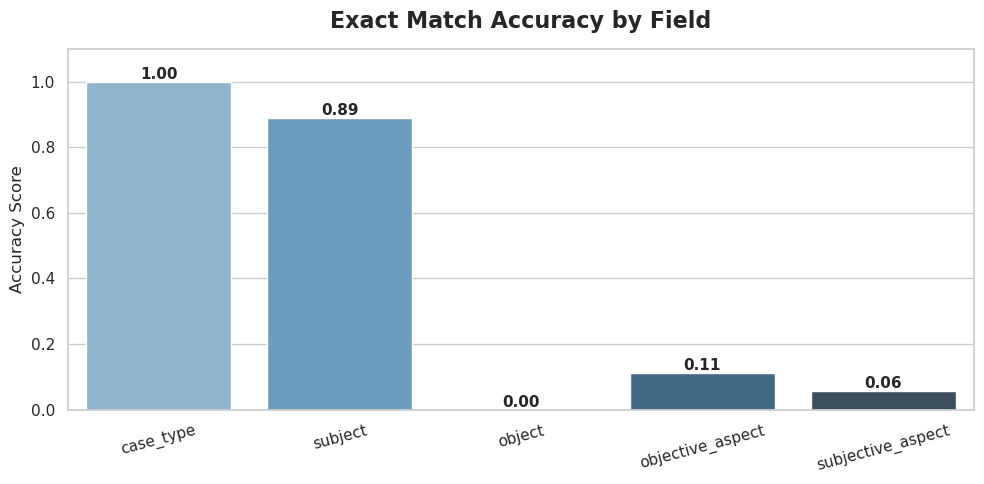

In [19]:
fields_em = ["case_type", "subject", "object", "objective_aspect", "subjective_aspect"]
em_scores = {}

for field in fields_em:
    acc = (
        df[f"{field}_gt"].astype(str).str.lower().str.strip() 
        == 
        df[f"{field}_pred"].astype(str).str.lower().str.strip()
    ).mean()
    em_scores[field] = acc

# --- Visualization ---
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(em_scores.keys()), y=list(em_scores.values()), palette="Blues_d")
plt.title("Exact Match Accuracy by Field", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("Accuracy Score", fontsize=12)
plt.ylim(0, 1.1)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 3. Token F1 Score Evaluation
Exact match is often too strict. Token F1 measures the overlap of individual words between the prediction and ground truth.

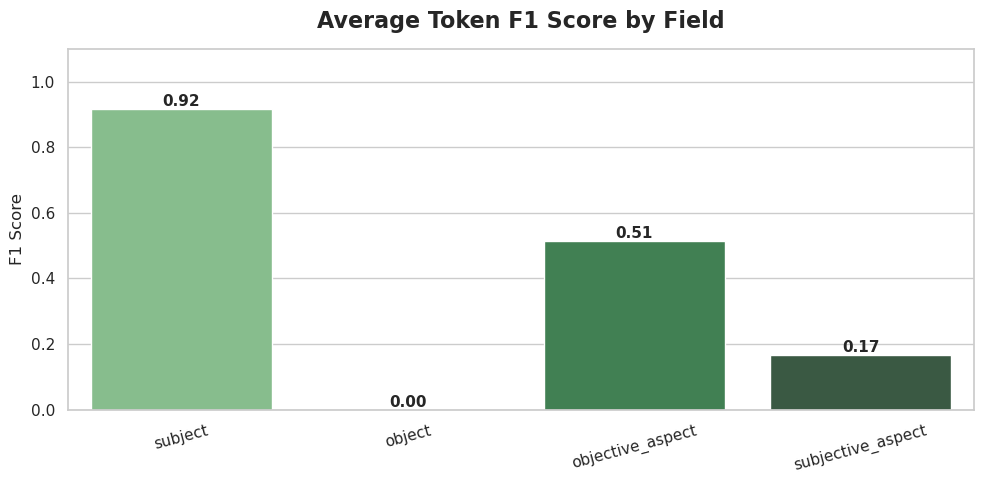

In [20]:
def token_f1(gt, pred):
    gt_tokens = set(str(gt).lower().split())
    pred_tokens = set(str(pred).lower().split())
    
    tp = len(gt_tokens.intersection(pred_tokens))
    precision = tp / max(len(pred_tokens), 1)
    recall = tp / max(len(gt_tokens), 1)
    
    if precision + recall == 0:
        return 0
    return (2 * precision * recall) / (precision + recall)

fields_f1 = ["subject", "object", "objective_aspect", "subjective_aspect"]
f1_scores = {}

for field in fields_f1:
    scores = [token_f1(row[f"{field}_gt"], row[f"{field}_pred"]) for _, row in df.iterrows()]
    f1_scores[field] = np.mean(scores)

# --- Visualization ---
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()), palette="Greens_d")
plt.title("Average Token F1 Score by Field", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("F1 Score", fontsize=12)
plt.ylim(0, 1.1)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 4. NLP Generation Metrics (Reasoning)
Evaluating the long-form "reasoning" field using ROUGE (n-gram overlap) and BERTScore (semantic similarity).

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


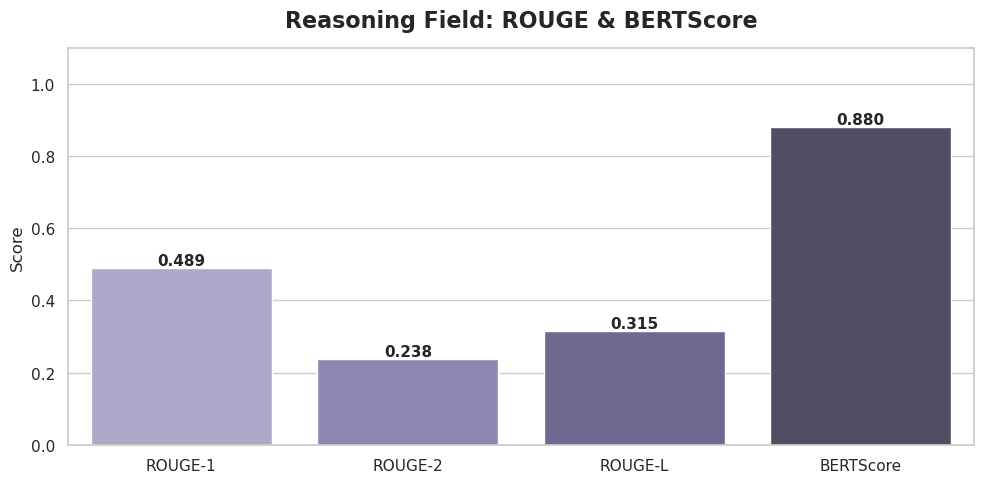

In [21]:
# 1. ROUGE Scores
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
r1, r2, rl = [], [], []

for _, row in df.iterrows():
    score_dict = scorer.score(str(row["reasoning_gt"]), str(row["reasoning_pred"]))
    r1.append(score_dict["rouge1"].fmeasure)
    r2.append(score_dict["rouge2"].fmeasure)
    rl.append(score_dict["rougeL"].fmeasure)

rouge_results = {
    "ROUGE-1": np.mean(r1),
    "ROUGE-2": np.mean(r2),
    "ROUGE-L": np.mean(rl)
}

# 2. BERTScore
predictions = df["reasoning_pred"].astype(str).tolist()
references = df["reasoning_gt"].astype(str).tolist()

P, R, F1 = score(predictions, references, lang="en", verbose=False)
bert_score_val = F1.mean().item()

# Combine metrics for visualization
generation_metrics = {**rouge_results, "BERTScore": bert_score_val}

# --- Visualization ---
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(generation_metrics.keys()), y=list(generation_metrics.values()), palette="Purples_d")
plt.title("Reasoning Field: ROUGE & BERTScore", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.1)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERTScore F1 for object: 0.8096


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERTScore F1 for objective_aspect: 0.9193


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERTScore F1 for subjective_aspect: 0.8464


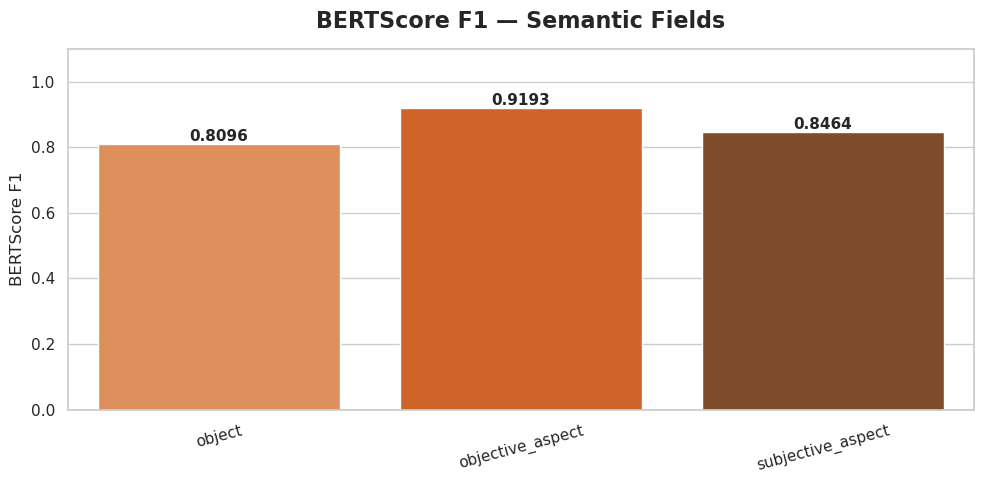

In [22]:
# ============================================================
# BERTScore for Semantic Fields (object, objective_aspect, subjective_aspect)
# ============================================================
from bert_score import score as bert_score_fn

semantic_fields = ["object", "objective_aspect", "subjective_aspect"]
bert_scores_by_field = {}

for field in semantic_fields:
    preds = df[f"{field}_pred"].astype(str).tolist()
    refs = df[f"{field}_gt"].astype(str).tolist()
    
    P, R, F1 = bert_score_fn(preds, refs, lang="en", verbose=False)
    bert_scores_by_field[field] = round(F1.mean().item(), 4)
    print(f"BERTScore F1 for {field}: {bert_scores_by_field[field]}")

# --- Visualization ---
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=list(bert_scores_by_field.keys()), 
    y=list(bert_scores_by_field.values()), 
    palette="Oranges_d"
)
plt.title("BERTScore F1 — Semantic Fields", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("BERTScore F1", fontsize=12)
plt.ylim(0, 1.1)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 5. Final Evaluation Summary
A consolidated view of the generation metrics.

In [23]:
# Display as a beautifully formatted Pandas DataFrame
final_results_df = pd.DataFrame([generation_metrics])
final_results_df.index = ["Qwen2.5-14B Performance"]

# Style the dataframe output
final_results_df.style.set_properties(**{
    'background-color': '#f8f9fa',
    'color': 'black',
    'border-color': 'white',
    'font-size': '11pt'
}).format("{:.4f}")

,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore
Qwen2.5-14B Performance,0.4893,0.2382,0.3150,0.8796


## COMPREHENSIVE MODEL EVALUATION DASHBOARD

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['ro

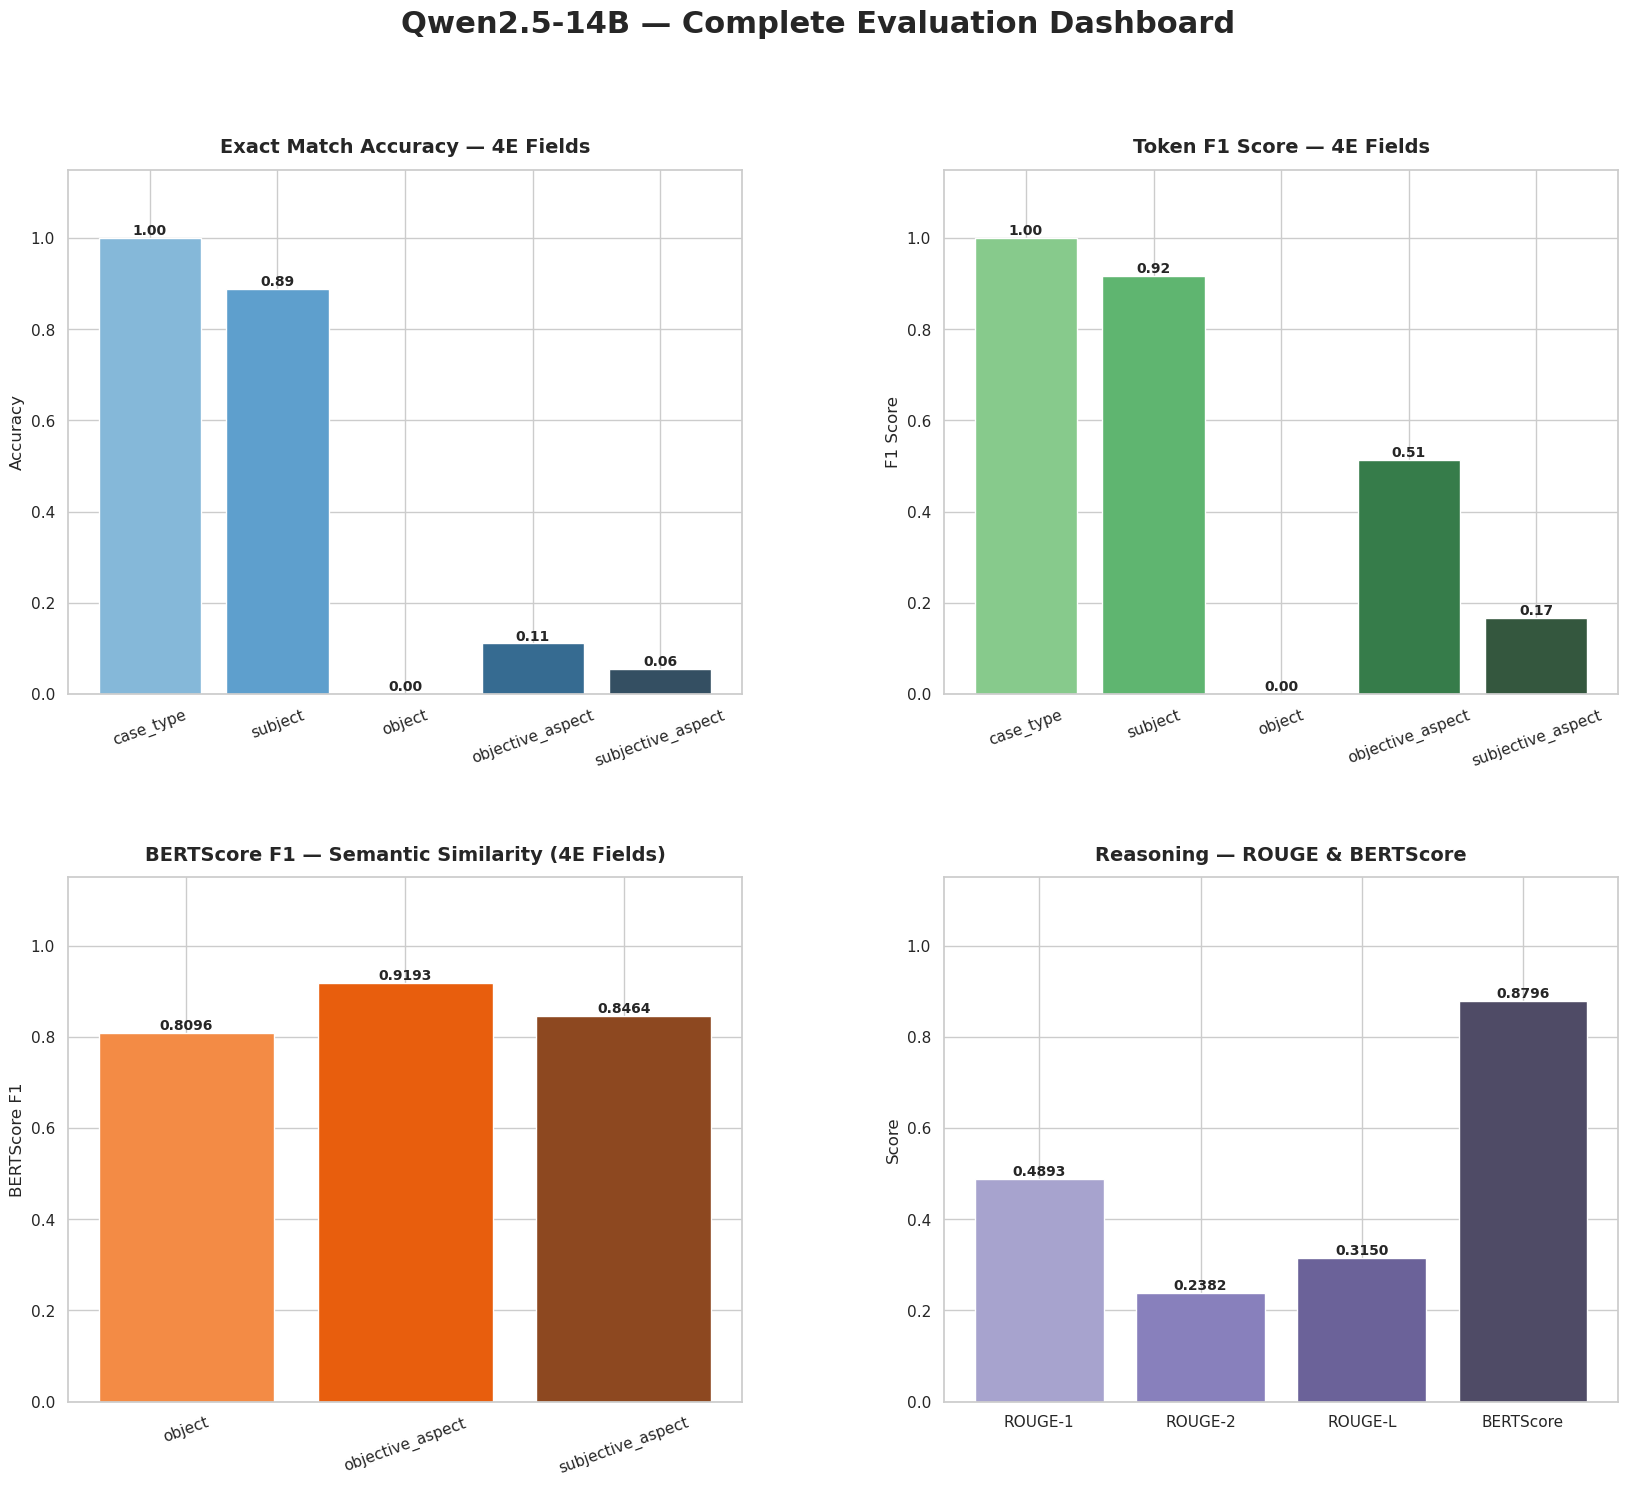


COMPLETE EVALUATION SUMMARY
      Metric case_type subject object objective_aspect subjective_aspect reasoning
 Exact Match    1.0000  0.8889 0.0000           0.1111            0.0556       N/A
    Token F1    1.0000  0.9167 0.0000           0.5129            0.1667       N/A
BERTScore F1       N/A     N/A 0.8096           0.9193            0.8464    0.8796
     ROUGE-1       N/A     N/A    N/A              N/A               N/A    0.4893
     ROUGE-2       N/A     N/A    N/A              N/A               N/A    0.2382
     ROUGE-L       N/A     N/A    N/A              N/A               N/A    0.3150


In [24]:
# ============================================================
# COMPREHENSIVE MODEL EVALUATION DASHBOARD
# ============================================================
from bert_score import score as bert_score_fn
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

# ---- 1. Exact Match for all 4E fields ----
fields_4e = ["case_type", "subject", "object", "objective_aspect", "subjective_aspect"]
em_scores = {}
for f in fields_4e:
    em_scores[f] = (
        df[f"{f}_gt"].astype(str).str.lower().str.strip() ==
        df[f"{f}_pred"].astype(str).str.lower().str.strip()
    ).mean()

# ---- 2. Token F1 for 4E fields ----
def token_f1(gt, pred):
    gt_tok = set(str(gt).lower().split())
    pred_tok = set(str(pred).lower().split())
    tp = len(gt_tok & pred_tok)
    prec = tp / max(len(pred_tok), 1)
    rec = tp / max(len(gt_tok), 1)
    return (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

f1_scores = {}
for f in fields_4e:
    f1_scores[f] = np.mean([token_f1(row[f"{f}_gt"], row[f"{f}_pred"]) for _, row in df.iterrows()])

# ---- 3. BERTScore for semantic fields ----
semantic_fields = ["object", "objective_aspect", "subjective_aspect"]
bert_4e = {}
for f in semantic_fields:
    preds = df[f"{f}_pred"].astype(str).tolist()
    refs = df[f"{f}_gt"].astype(str).tolist()
    _, _, F1 = bert_score_fn(preds, refs, lang="en", verbose=False)
    bert_4e[f] = round(F1.mean().item(), 4)

# ---- 4. ROUGE + BERTScore for reasoning ----
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
r1, r2, rl = [], [], []
for _, row in df.iterrows():
    gt = str(row["reasoning_gt"]).strip()
    pred = str(row["reasoning_pred"]).strip()
    if gt in ("", "nan", "Unknown") and pred in ("", "nan", "Unknown"):
        continue
    if gt in ("", "nan", "Unknown"): gt = "No reasoning provided."
    if pred in ("", "nan", "Unknown"): pred = "No reasoning provided."
    s = scorer.score(gt, pred)
    r1.append(s["rouge1"].fmeasure)
    r2.append(s["rouge2"].fmeasure)
    rl.append(s["rougeL"].fmeasure)

rouge_scores = {
    "ROUGE-1": np.mean(r1) if r1 else 0,
    "ROUGE-2": np.mean(r2) if r2 else 0,
    "ROUGE-L": np.mean(rl) if rl else 0,
}
preds_r = df["reasoning_pred"].astype(str).tolist()
refs_r = df["reasoning_gt"].astype(str).tolist()
_, _, F1_r = bert_score_fn(preds_r, refs_r, lang="en", verbose=False)
reasoning_bert = round(F1_r.mean().item(), 4)

# ============================================================
# SINGLE DASHBOARD — 4 charts in one figure
# ============================================================
fig = plt.figure(figsize=(20, 16))
fig.suptitle("Qwen2.5-14B — Complete Evaluation Dashboard", fontsize=22, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

# ---- Chart 1: Exact Match ----
ax1 = fig.add_subplot(gs[0, 0])
bars1 = ax1.bar(em_scores.keys(), em_scores.values(), color=sns.color_palette("Blues_d", len(em_scores)))
ax1.set_title("Exact Match Accuracy — 4E Fields", fontsize=14, fontweight="bold", pad=12)
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0, 1.15)
for b in bars1:
    ax1.annotate(f"{b.get_height():.2f}", (b.get_x() + b.get_width()/2, b.get_height()),
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.tick_params(axis="x", rotation=20)

# ---- Chart 2: Token F1 ----
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(f1_scores.keys(), f1_scores.values(), color=sns.color_palette("Greens_d", len(f1_scores)))
ax2.set_title("Token F1 Score — 4E Fields", fontsize=14, fontweight="bold", pad=12)
ax2.set_ylabel("F1 Score")
ax2.set_ylim(0, 1.15)
for b in bars2:
    ax2.annotate(f"{b.get_height():.2f}", (b.get_x() + b.get_width()/2, b.get_height()),
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.tick_params(axis="x", rotation=20)

# ---- Chart 3: BERTScore Semantic (4E fields) ----
ax3 = fig.add_subplot(gs[1, 0])
bars3 = ax3.bar(bert_4e.keys(), bert_4e.values(), color=sns.color_palette("Oranges_d", len(bert_4e)))
ax3.set_title("BERTScore F1 — Semantic Similarity (4E Fields)", fontsize=14, fontweight="bold", pad=12)
ax3.set_ylabel("BERTScore F1")
ax3.set_ylim(0, 1.15)
for b in bars3:
    ax3.annotate(f"{b.get_height():.4f}", (b.get_x() + b.get_width()/2, b.get_height()),
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
ax3.tick_params(axis="x", rotation=20)

# ---- Chart 4: Reasoning Metrics (ROUGE + BERTScore) ----
ax4 = fig.add_subplot(gs[1, 1])
reasoning_all = {**rouge_scores, "BERTScore": reasoning_bert}
bars4 = ax4.bar(reasoning_all.keys(), reasoning_all.values(), color=sns.color_palette("Purples_d", len(reasoning_all)))
ax4.set_title("Reasoning — ROUGE & BERTScore", fontsize=14, fontweight="bold", pad=12)
ax4.set_ylabel("Score")
ax4.set_ylim(0, 1.15)
for b in bars4:
    ax4.annotate(f"{b.get_height():.4f}", (b.get_x() + b.get_width()/2, b.get_height()),
                 ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.savefig("evaluation_dashboard_for10_sample.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Summary Table ----
print("\n" + "="*70)
print("COMPLETE EVALUATION SUMMARY")
print("="*70)

summary = {
    "Metric": [],
    "case_type": [], "subject": [], "object": [],
    "objective_aspect": [], "subjective_aspect": [], "reasoning": []
}

# Exact Match row
summary["Metric"].append("Exact Match")
for f in fields_4e:
    summary[f].append(f"{em_scores[f]:.4f}")
summary["reasoning"].append("N/A")

# Token F1 row
summary["Metric"].append("Token F1")
for f in fields_4e:
    summary[f].append(f"{f1_scores[f]:.4f}")
summary["reasoning"].append("N/A")

# BERTScore row
summary["Metric"].append("BERTScore F1")
summary["case_type"].append("N/A")
summary["subject"].append("N/A")
for f in semantic_fields:
    summary[f].append(f"{bert_4e[f]:.4f}")
summary["reasoning"].append(f"{reasoning_bert:.4f}")

# ROUGE rows
for rname, rval in rouge_scores.items():
    summary["Metric"].append(rname)
    for f in fields_4e:
        summary[f].append("N/A")
    summary["reasoning"].append(f"{rval:.4f}")

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))